In [1]:
# Importing tests -> Succesful on 15/02/2026

import time
import pandas as pd
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds

2026-02-25 19:46:49.918230: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-25 19:46:49.963737: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-25 19:46:50.269761: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-25 19:46:50.269865: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-25 19:46:50.347781: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to

In [2]:
import tensorflow_recommenders as tfrs

# Recommenders Introduction
Based on [Basic Retreival Models](https://www.tensorflow.org/recommenders/examples/basic_retrieval) and  [Basic Ranking Models](https://www.tensorflow.org/recommenders/examples/basic_ranking)


Real-world recommender systems are often composed of two stages:

- The retrieval stage is responsible for selecting an initial big set of candidates from all possible candidates. The main objective of this model is to efficiently weed out all candidates that the user/customer is not interested in. Because the retrieval model may be dealing with millions of candidates, it has to be computationally efficient. 
- The ranking stage takes the outputs of the retrieval model and fine-tunes them to select the best possible handful of recommendations based on a numeric valuation that the user/client to the product. This numeric value can be a explicit such a rating or implicit 

In real word scenarios, it is almost mandatory a third stage where business rules are applied to re-rank recommendations. This are usually deterministic rules set by business requirements such as: "If this product appears in the ranking, show it first" or "To these type of customer do not show this kind of product". It is out of the scope of this notebook that step. 

## Two towers models
The Two-Tower model is a deep learning architecture that maps users (queries) and items (candidates) into a shared multi-dimensional vector space. By encoding complex features into high-dimensional embeddings, the model allows us to calculate the affinity between a user and an item using simple vector operations like the dot product or cosine similarity. This mathematical decoupling ensures that we can scale to millions of items by pre-computing item vectors and using efficient nearest-neighbor searches.

**Note on naming conventions**

For retrieval  stage, it is customary to use the terms "Candidate Model" and "Query Model" to name each of the towers. "Candidate" refers to the possible items to be recommended and "Query" to the context we have for those items to be recommended. 

For ranking stage "Rating Model" is normally used. "Rating" refers to the  valuation of the item by the user/customer. 

In the context of this notebook the following applies:

- Query Model is equivalent to Client Model
- Candidate Model is equivalent to Product Model



# Developement

## Data Preparation ETL

The data used for this demonstrations comes [from this dataset](https://github.com/dluckyaction/datasets/blob/main/sales/README.md): *Sales data from beverage products on B2B setting*

### Extractions

In [3]:
file_paths ={"clients":"https://raw.githubusercontent.com/dluckyaction/datasets/refs/heads/main/sales/clients.csv",
             "products":"https://raw.githubusercontent.com/dluckyaction/datasets/refs/heads/main/sales/products.csv",
             "sales":"https://raw.githubusercontent.com/dluckyaction/datasets/refs/heads/main/sales/sales.csv" } 

In [4]:
products_df = pd.read_csv(file_paths.get("products"))
sales_df = pd.read_csv(file_paths.get("sales"))

### Transformation

In [5]:
# Converting purchase date into dates to be able to split train/test
sales_df["day"]=pd.to_datetime(sales_df["day"])

#### Train test dataframes

In [6]:
# Cutoff date chosen to train set represent 80% of the dates of sales
cutoff_date = sales_df["day"].min()+(sales_df['day'].max() - sales_df['day'].min())*0.8
train_df = sales_df[sales_df["day"]<=cutoff_date].drop(columns=["day","units"])
test_df = sales_df[sales_df["day"]>cutoff_date].drop(columns=["day","units"])

#### Unique Clients/Products

Extraction of unique clients and products to define Product and Client models (towers)

In [7]:
unique_clients=sales_df.client_code.unique().to_numpy()
unique_products=sales_df.product_code.unique().to_numpy()

### Start up Tensorflow data structures

In order to correctly init the models, metrics and tasks on tensorflow, the dataframe and numpy arrays must be transformed into tensors

In [8]:
# 1. Convert NumPy array to a TF Dataset (a stream of strings)
unique_product_tf_dataset = tf.data.Dataset.from_tensor_slices(unique_products)

# 2. Batch and Map
# We batch them so the GPU/CPU processes 64 at a time instead of 1 by 1
# Then we pass those batches through your product_model (the embedding tower)


train_tf_dsataset = tf.data.Dataset.from_tensor_slices({
    "client_code": train_df["client_code"].values.astype(str),
    "product_code": train_df["product_code"].values.astype(str)
})

test_tf_dsataset = tf.data.Dataset.from_tensor_slices({
    "client_code": test_df["client_code"].values.astype(str),
    "product_code": test_df["product_code"].values.astype(str)
})


##  Models

Building two towers. For this scenario we only use the identification of customers and products.

## Parameters
*models parameters*

In [9]:
# Models parameters
EMBEDDING_DIMENSION = 32 # Size of the vectorial 
                         #representation of clients and products ids
EPOCHS = 10 # Number of epochs
METRIC_FACTORIZED_KTOPS = [1, 5, 10, 50]
LEARNING_RATE=0.01
# Data parameters
## Batch sizes
### train/test batches
METRIC_CANDIDATE_BATCH_SIZE=64
TRAIN_BATCH_SIZE = 128
TEST_BATCH_SIZE = 128


### Query/Clients and Candidate/Products models

In [10]:
clients_model = tf.keras.Sequential([
  tf.keras.layers.StringLookup(
      vocabulary=unique_clients, mask_token=None),
  # We add an additional embedding to account for unknown tokens.
  tf.keras.layers.Embedding(len(unique_clients) + 1, EMBEDDING_DIMENSION)
],name="clients_model" )

products_model = tf.keras.Sequential([
  tf.keras.layers.StringLookup(
      vocabulary=unique_products, mask_token=None),
  # We add an additional embedding to account for unknown tokens.
  tf.keras.layers.Embedding(len(unique_products) + 1, EMBEDDING_DIMENSION)
], name="products_model")


### Metrics

#### Factorize Top-K 

- [Factorize Top-K](https://www.tensorflow.org/recommenders/api_docs/python/tfrs/metrics/FactorizedTopK)
- [Explained](https://iamirmasoud.com/2022/04/30/understanding-factorized-top-k-factorizedtopk-metric-for-recommendation-systems-with-example/)



In [11]:
candidate_embeddings = unique_product_tf_dataset.batch(METRIC_CANDIDATE_BATCH_SIZE).map(products_model)
metrics = tfrs.metrics.FactorizedTopK(
  candidates=candidate_embeddings,# The embeddings need to be passed to the metric as it 
  ks=METRIC_FACTORIZED_KTOPS              # computes user/client/query and all products/candidates  
)                                 # dot product

## Retrieval Task

> **What is a "Task"?**
>
>In TensorFlow Recommenders, a Task is a clever abstraction that wraps your Loss function and your Metrics into one convenient object. The  "Supervisor" of the learning process. In a standard Keras model, you usually define your loss (like `MeanSquaredError`) and your metrics (like `Accuracy`) inside the `.compile()` method.  In Recommenders, things are more complex. To calculate a loss, you need to compare a "User Query" vector against a "Candidate" vector. A Task takes that responsibility away from the main model logic. It says: "Give me the vectors, and I will handle the math to figure out how wrong the model was (Loss) and how good the recommendations are (Metrics)."

 **What is a " Retieval Task"?**
Once the metric is well instatiated a special type of layer called Task needs to be created. This is a specific type of layer for recommenders. The goal of Retrieval is to find a few hundred relevant items out of a catalog of millions. When you call task(user_embeddings, product_embeddings), the Retrieval task performs these three steps:

- A. The Similarity Calculation. It computes the Inner Product (dot product) between the batch of users and the batch of products.$$\text{Score} = \text{UserVector} \cdot \text{ProductVector}$$
A high score means the model thinks the user and product are a good match.
- B. The Loss Computation (Categorical Cross-Entropy)This is the "Dual Encoder" logic. The task treats the batch as a giant multiple-choice quiz:
    - Positive Pair: The product the user actually bought. The model wants the score for this pair to be very high.
    - Negative Pairs: All other products in the current batch. The model treats these as "accidental negatives" and wants their scores to be low.It uses In-batch Softmax Loss. It tries to maximize the probability of the actual product versus all other products in that specific batch.
- C. The Metric UpdateIt uses those same scores to update the FactorizedTopK metrics you defined earlier. It checks if the "True Product" is sitting in the top 10, 50, or 100 highest scores.


In [12]:
task = tfrs.tasks.Retrieval(
  metrics=metrics # more metrics could be added here if ya want!
)

## Full Basic Retrieval Model

In [13]:
class BasicRetrievalModel(tfrs.Model):

  def __init__(self, products_model, clients_model):
    super().__init__()
    self.products_model: tf.keras.Model = products_model
    self.clients_model: tf.keras.Model = clients_model
    self.task: tf.keras.layers.Layer = task

  def compute_loss(self, features : pd.DataFrame,training=False) -> tf.Tensor:
    # We pick out the user features and pass them into the user model.
    client_embeddings = self.clients_model(features["client_code"])
    # And pick out the movie features and pass them into the movie model,
    # getting embeddings back.
    positive_product_embeddings = self.products_model(features["product_code"])

    # The task computes the loss and the metrics.
    return self.task(client_embeddings, positive_product_embeddings)

### Train

In [14]:
model = BasicRetrievalModel(products_model,clients_model)
model.compile(optimizer=tf.keras.optimizers.Adagrad(learning_rate=LEARNING_RATE))

In [15]:
cached_train = train_tf_dsataset.shuffle(len(train_df)).batch(TRAIN_BATCH_SIZE).cache()
cached_test = test_tf_dsataset.batch(TEST_BATCH_SIZE).cache() # THIS BATCH SIZE MUST BE A PARAMETERRRRR 

In [16]:
# Saving results of fit (history) is useful to visualize training process
history = model.fit(cached_train, epochs=EPOCHS)

Epoch 1/10
1402/1402 [==============================] - 57s 39ms/step - factorized_top_k/top_1_categorical_accuracy: 0.0028 - factorized_top_k/top_5_categorical_accuracy: 0.2137 - factorized_top_k/top_10_categorical_accuracy: 0.3815 - factorized_top_k/top_50_categorical_accuracy: 0.7195 - loss: 596.5614 - regularization_loss: 0.0000e+00 - total_loss: 596.5614
Epoch 2/10
1402/1402 [==============================] - 53s 38ms/step - factorized_top_k/top_1_categorical_accuracy: 0.0094 - factorized_top_k/top_5_categorical_accuracy: 0.2482 - factorized_top_k/top_10_categorical_accuracy: 0.4503 - factorized_top_k/top_50_categorical_accuracy: 0.8423 - loss: 554.7236 - regularization_loss: 0.0000e+00 - total_loss: 554.7236
Epoch 3/10
1402/1402 [==============================] - 52s 37ms/step - factorized_top_k/top_1_categorical_accuracy: 0.0124 - factorized_top_k/top_5_categorical_accuracy: 0.2625 - factorized_top_k/top_10_categorical_accuracy: 0.4541 - factorized_top_k/top_50_categorical_accur

#### Visualize Train

##### Evolution of Loss and selected metric accross epochs

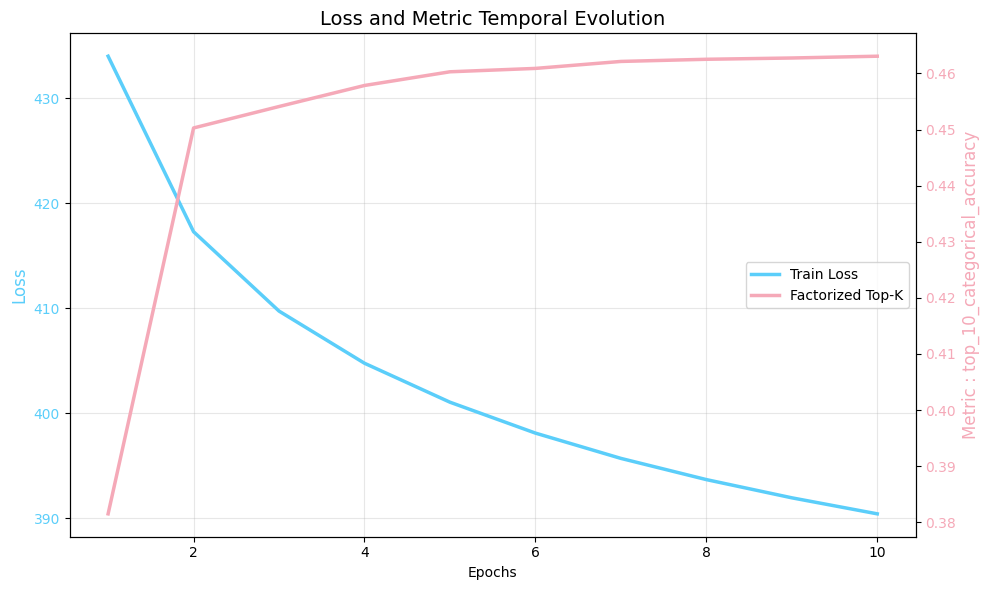

In [17]:
import matplotlib.pyplot as plt


metric_key = "factorized_top_k/top_10_categorical_accuracy"
loss_key = "loss"
x_values= range(1,len(history.history[loss_key])+1)
fig, ax1 = plt.subplots(figsize=(10, 6))

color_loss = '#5BCEFA' # Light Blue
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss', color=color_loss, fontsize=12)
line1 = ax1.plot(x_values,history.history[loss_key], color=color_loss, label='Train Loss', lw=2.5)
ax1.tick_params(axis='y', labelcolor=color_loss)
ax1.grid(True, alpha=0.3)

# 3. Create the second axis (Metric)
ax2 = ax1.twinx() 
color_metric = '#F5A9B8' # Light Pink
# Using LaTeX for the label as per scientific notation standards
ax2.set_ylabel(f'Metric : {metric_key.replace("_"," ").capitalize()}', color=color_metric, fontsize=12)
line2 = ax2.plot(x_values,history.history[metric_key], color=color_metric, label=f'Metric : {metric_key.replace("_"," ").capitalize()}', lw=2.5)
ax2.tick_params(axis='y', labelcolor=color_metric)

# 4. Merging legends
# Since we have two axes, we combine the lines into a single legend box
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='center right', frameon=True)

plt.title('Loss and Metric Temporal Evolution', fontsize=14)
fig.tight_layout()

# 5. Save/Show
# In WSL/Notebooks, savefig is often more reliable than show()
# plt.savefig('training_evolution.png', dpi=300)
plt.show()

### Model Evaluation

Make predictions from test dataset

In [18]:
evaluation = model.evaluate(cached_test, return_dict=True)

438/438 [==============================] - 16s 37ms/step - factorized_top_k/top_1_categorical_accuracy: 0.0506 - factorized_top_k/top_5_categorical_accuracy: 0.2656 - factorized_top_k/top_10_categorical_accuracy: 0.4289 - factorized_top_k/top_50_categorical_accuracy: 0.8681 - loss: 592.5395 - regularization_loss: 0.0000e+00 - total_loss: 592.5395


#### Comparing results

In [25]:
# This is a toy evaluation. For production grade models
# be professional and use optuna and mlflow (or equivalent tools) 
# to automate evaluation
compare_metric = 'factorized_top_k/top_10_categorical_accuracy'
loss= 'loss'
evaluation

train_metric = history.history[compare_metric][-1] # Assuming last epoch as the best lol
eval_metric = evaluation[compare_metric]
train_loss = history.history[loss][-1] # Assuming last epoch as the best lol
eval_loss = evaluation[loss]

metric_ratio = train_metric/eval_metric
loss_ratio = train_loss/eval_loss

print(f"{compare_metric} ratio train vs test:   {metric_ratio}")
print(f"{loss} ratio train vs test:   {loss_ratio}")

factorized_top_k/top_10_categorical_accuracy ratio train vs test:   1.0795710123459707
loss ratio train vs test:   0.6468793140883341


### Making Recommmendations (predictions)

#### Brute Force ("exact" prediction)

This approach, given a single client, it calculates every client*product dot product to estimate an affinity and sorts the results. This brute force method is SLOW.

In [20]:
# Defining number or recommendations and test client
n_rec=5
test_client = unique_clients[np.random.randint(0, len(unique_clients),size=1)[0]]


# Measuring 
start_time = time.time()

# 1) Create a model that takes in raw query features
index = tfrs.layers.factorized_top_k.BruteForce(model.clients_model)
# recommends movies out of the entire movies dataset.
index.index_from_dataset(
  tf.data.Dataset.zip((unique_product_tf_dataset.batch(25), unique_product_tf_dataset.batch(25).map(model.products_model)))
)

# Get recommendations.
_, products_recommended = index(tf.constant([test_client]))
recs= '\n'.join([str(s) for s in list(products_recommended.numpy()[0][0:n_rec])])

end_time = time.time()
elapsed_seconds_bruteforce = end_time - start_time
print(f"Recommnedations for client {test_client} performed in {elapsed_seconds_bruteforce:.4f} seconds ")
print(f"Top {n_rec} Recomendations: \n {recs}")

Recommnedations for client 1a50b88a1c performed in 0.0765 seconds 
Top 5 Recomendations: 
 b'4f9449ddda'
b'4006db3eef'
b'20337e3da8'
b'4540a3935f'
b'c1ce11a92e'


#### Approximate Recommendations

Bruteforce approach can be quite consuming computationally-wise. For larger datsets (in the order of millions of possible retrievals). This can be done using [ScaNN](https://github.com/google-research/google-research/tree/master/scann),a method for efficient vector similarity search at scale.

In [21]:
start_time = time.time()
scann_index = tfrs.layers.factorized_top_k.ScaNN(model.clients_model)
scann_index.index_from_dataset(
  tf.data.Dataset.zip((unique_product_tf_dataset.batch(25), unique_product_tf_dataset.batch(25).map(model.products_model)))
)


# Get recommendations.
_, products_recommended = index(tf.constant([test_client]))
recs= '\n'.join([str(s) for s in list(products_recommended.numpy()[0][0:n_rec])])
end_time = time.time()
elapsed_seconds_scann = end_time - start_time
print(f"Recommnedations for client {test_client}  in {elapsed_seconds_scann:.4f} seconds")
print(f"Top {n_rec} Recomendations: \n {recs}")

Recommnedations for client 1a50b88a1c  in 0.1262 seconds
Top 5 Recomendations: 
 b'4f9449ddda'
b'4006db3eef'
b'20337e3da8'
b'4540a3935f'
b'c1ce11a92e'


2026-02-25 19:56:21.037980: I scann/partitioning/partitioner_factory_base.cc:59] Size of sampled dataset for training partition: 229
2026-02-25 19:56:21.044170: W scann/utils/gmm_utils.cc:921] Could not normalize centroid due to zero norm or empty or zero-weight partition.
2026-02-25 19:56:21.044931: I ./scann/partitioning/kmeans_tree_partitioner_utils.h:88] PartitionerFactory ran in 6.799644ms.


# Appendix 1: Visualizing Models

In [22]:
## Example model
example_model = tf.keras.Sequential([
  tf.keras.layers.StringLookup(
      vocabulary=unique_clients, mask_token=None),
  # We add an additional embedding to account for unknown tokens.
  tf.keras.layers.Embedding(len(unique_clients) + 1, EMBEDDING_DIMENSION)
], name="example_model")

example_model(unique_clients[:38]) 


<tf.Tensor: shape=(38, 32), dtype=float32, numpy=
array([[-0.00934223, -0.01942891, -0.03685189, ...,  0.03689135,
        -0.02666121,  0.0099986 ],
       [ 0.00923872, -0.01004586, -0.0224    , ...,  0.00231009,
        -0.00660593, -0.023771  ],
       [-0.03422501,  0.01723266, -0.0261708 , ...,  0.04266043,
         0.02671402, -0.03677553],
       ...,
       [-0.027279  ,  0.02321053, -0.03074526, ...,  0.0138484 ,
         0.01174925, -0.04786937],
       [ 0.03076797,  0.01318042, -0.01635836, ...,  0.02868838,
        -0.00589669, -0.03524766],
       [ 0.01597556,  0.02200982, -0.02071846, ...,  0.03461412,
         0.03739941,  0.03709617]], dtype=float32)>

## Summary of layers and dimensions

In [23]:
print(products_model.summary())

Model: "products_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 string_lookup_1 (StringLoo  (None,)                   0         
 kup)                                                            
                                                                 
 embedding_1 (Embedding)     (None, 32)                7360      
                                                                 
Total params: 7360 (28.75 KB)
Trainable params: 7360 (28.75 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
None


## Visualizing matrix weights

In [24]:
weights = products_model.layers[1].get_weights()[0]

print(f"Shape of the embedding matrix: {weights.shape}")
print("First client's vector:")
print(weights[0]) # Index 0 is usually the 'out-of-vocabulary' bucket

Shape of the embedding matrix: (230, 32)
First client's vector:
[-0.02807968 -0.02268622 -0.03268208  0.035476   -0.01269059 -0.00467452
  0.02435001 -0.0498122  -0.00457313 -0.04377606  0.00063723  0.0164184
 -0.01279167 -0.0141829  -0.03086107  0.02770728  0.00240003  0.02893091
 -0.04063614  0.00830894  0.0028831  -0.01419779 -0.00723095 -0.03780465
 -0.0222424   0.04166703 -0.03233565  0.03895462 -0.00790051  0.01011437
 -0.04460875  0.02929511]
